Лабораторная работа №4: Поиск ассоциативных правил в транзакционных данных

Датасет: Groceries

Описание: Набор транзакционных данных продуктового магазина. Каждая строка представляет собой отдельную покупку (чек), содержащую список приобретённых товаров.

Цель: Освоить методы поиска ассоциативных правил, реализовать алгоритмы Apriori и FP-Growth «с нуля», применить их к реальным и синтетическим данным, сравнить производительность и интерпретировать результаты.

In [2]:
!pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 6.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import time
import random

from itertools import combinations, chain
from collections import defaultdict, OrderedDict

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PALETTE = 'tab10'

# Фиксируем seed для воспроизводимости
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Все библиотеки загружены.")

Все библиотеки загружены.


Задание 1. Выбор и загрузка реального датасета

Источник: датасет Groceries — набор транзакционных данных продуктового магазина. Каждая строка CSV-файла соответствует одной покупке и содержит список приобретённых товаров.

In [14]:
# Загрузка датасета
raw_df = pd.read_csv('./groceries.csv', sep=';')

print(f"Размер таблицы: {raw_df.shape}")

raw_df.head()

Размер таблицы: (9834, 1)


,"citrus fruit,semi-finished bread,margarine,ready soups"
0,"tropical fruit,yogurt,coffee"
1,whole milk
2,"pip fruit,yogurt,cream cheese,meat spreads"
3,"other vegetables,whole milk,condensed milk,lon..."
4,"whole milk,butter,yogurt,rice,abrasive cleaner"


In [15]:
# Предобработка: преобразуем строки датасета в транзакции

transactions = []

for items in raw_df.iloc[:, 0]:
    
    # Проверяем, что строка не пустая
    if pd.notna(items):
        
        # Разделяем товары по запятой
        transaction = set()
        
        for item in str(items).split(','):
            item = item.strip().lower()
            
            if item:
                transaction.add(item)
        
        # Добавляем только непустые транзакции
        if transaction:
            transactions.append(frozenset(transaction))

print(f"Количество транзакций: {len(transactions)}")

Количество транзакций: 9834


In [16]:
# Базовая статистика
all_items = set()
lengths = []
for t in transactions:
    all_items.update(t)
    lengths.append(len(t))

print(f"Количество уникальных элементов: {len(all_items)}")
print(f"Средняя длина транзакции: {np.mean(lengths):.2f}")
print(f"Медианная длина транзакции: {np.median(lengths):.1f}")
print(f"Минимальная длина транзакции: {np.min(lengths)}")
print(f"Максимальная длина транзакции: {np.max(lengths)}")

Количество уникальных элементов: 169
Средняя длина транзакции: 4.41
Медианная длина транзакции: 3.0
Минимальная длина транзакции: 1
Максимальная длина транзакции: 32


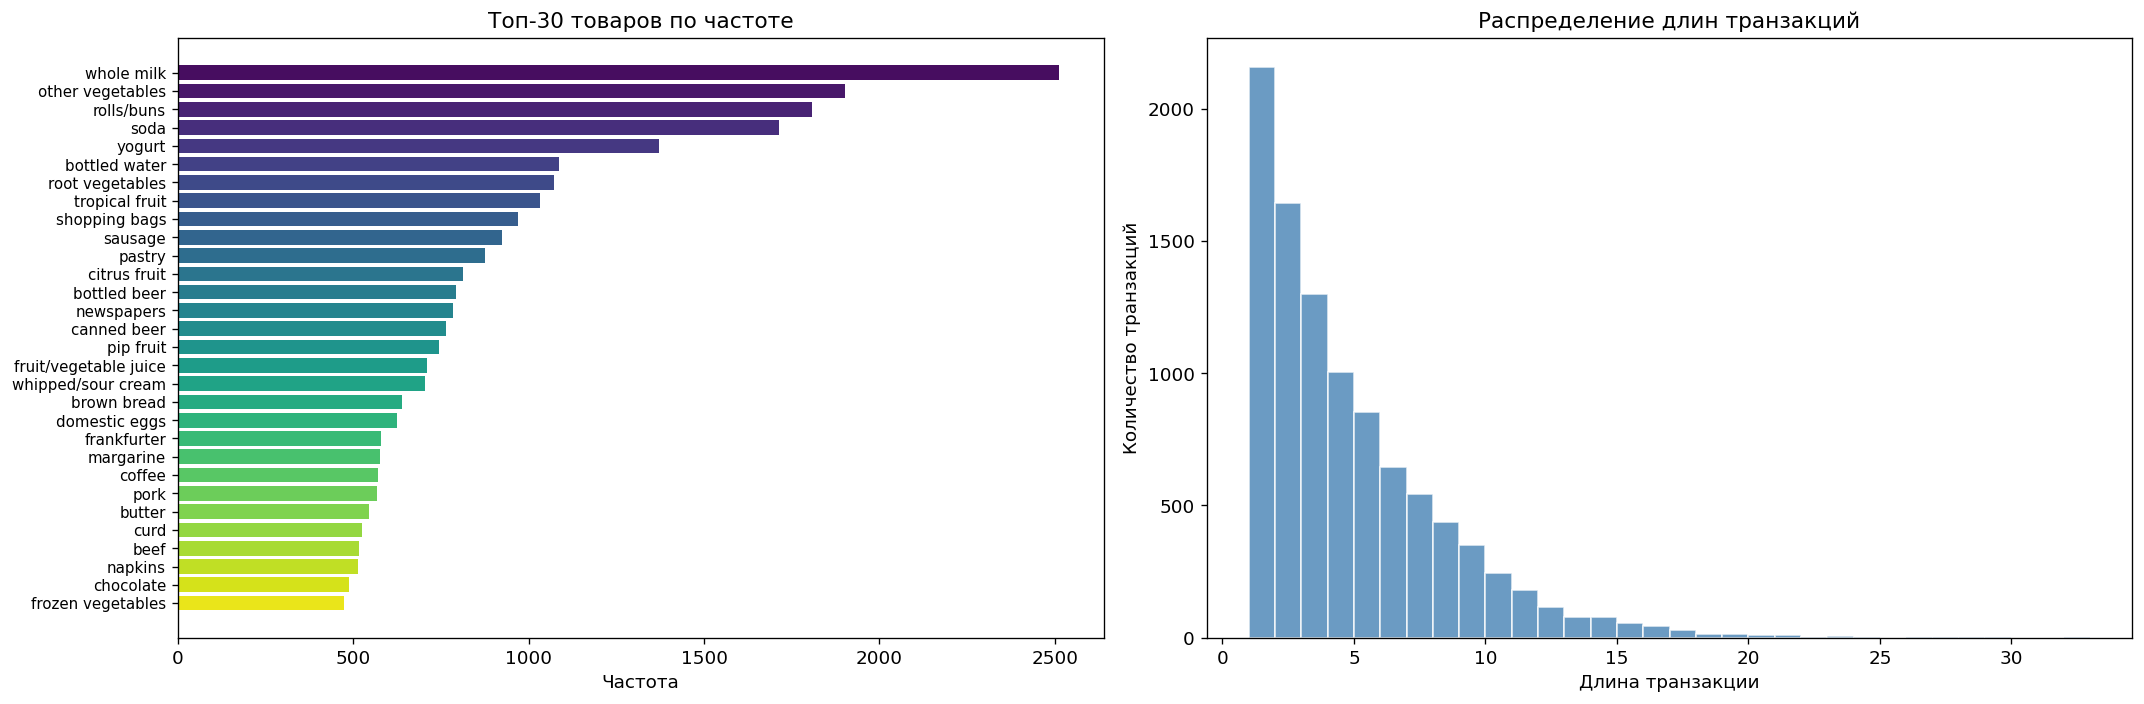

In [17]:
# Распределение частот элементов

item_counts = defaultdict(int)

for transaction in transactions:
    for item in transaction:
        item_counts[item] += 1

# Сортировка товаров по убыванию частоты
sorted_items = sorted(item_counts.items(), key=lambda x: x[1], reverse=True)

# Топ-30 самых популярных товаров
top_30 = sorted_items[:30]

items_names = [x[0] for x in top_30]
items_freqs = [x[1] for x in top_30]

# Длины транзакций
lengths = [len(t) for t in transactions]

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График топ-30 товаров
axes[0].barh(
    range(len(items_names)),
    items_freqs,
    color=sns.color_palette('viridis', len(items_names))
)

axes[0].set_yticks(range(len(items_names)))
axes[0].set_yticklabels(items_names, fontsize=9)

axes[0].invert_yaxis()

axes[0].set_xlabel('Частота')
axes[0].set_title('Топ-30 товаров по частоте')

# Гистограмма длин транзакций
axes[1].hist(
    lengths,
    bins=range(1, max(lengths) + 2),
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)

axes[1].set_xlabel('Длина транзакции')
axes[1].set_ylabel('Количество транзакций')

axes[1].set_title('Распределение длин транзакций')

plt.tight_layout()
plt.show()

Задание 2. Реализация алгоритма Apriori

In [18]:
def apriori_gen(prev_frequent_items, k):
    """
    Генерация кандидатов размера k
    из частых наборов размера k-1.
    """
    
    candidates = set()
    
    prev_list = sorted(prev_frequent_items)
    n = len(prev_list)

    for i in range(n):
        for j in range(i + 1, n):

            l1 = list(prev_list[i])
            l2 = list(prev_list[j])

            # Объединяем наборы,
            # если первые k-2 элементов совпадают
            if l1[:k - 2] == l2[:k - 2]:

                candidate = frozenset(prev_list[i]) | frozenset(prev_list[j])

                if len(candidate) == k:

                    # Проверка:
                    # все подмножества должны быть частыми
                    prev_set = set(map(frozenset, prev_list))

                    all_subsets_frequent = True

                    for item in candidate:

                        subset = candidate - frozenset([item])

                        if subset not in prev_set:
                            all_subsets_frequent = False
                            break

                    if all_subsets_frequent:
                        candidates.add(candidate)

    return candidates


def apriori(transactions, min_support):
    """
    Алгоритм Apriori для поиска
    частых наборов элементов.
    """

    n_transactions = len(transactions)

    min_count = min_support * n_transactions

    # Подсчёт одиночных элементов
    item_counts = defaultdict(int)

    for transaction in transactions:
        for item in transaction:
            item_counts[frozenset([item])] += 1

    # Оставляем только частые наборы
    current_frequent = {

        item: count

        for item, count in item_counts.items()

        if count >= min_count
    }

    # Итоговый словарь
    all_frequent = {}

    for itemset, count in current_frequent.items():

        key = tuple(sorted(itemset))

        all_frequent[key] = count / n_transactions

    k = 2

    while current_frequent:

        # Подготовка наборов
        prev_keys = [
            tuple(sorted(fs))
            for fs in current_frequent.keys()
        ]

        # Генерация кандидатов
        candidates = apriori_gen(prev_keys, k)

        if not candidates:
            break

        # Подсчёт поддержки кандидатов
        candidate_counts = defaultdict(int)

        for transaction in transactions:

            for candidate in candidates:

                if candidate.issubset(transaction):
                    candidate_counts[candidate] += 1

        # Фильтрация по support
        current_frequent = {

            candidate: count

            for candidate, count in candidate_counts.items()

            if count >= min_count
        }

        # Сохраняем результат
        for itemset, count in current_frequent.items():

            key = tuple(sorted(itemset))

            all_frequent[key] = count / n_transactions

        k += 1

    return all_frequent


print("Функция apriori() реализована.")

Функция apriori() реализована.


In [19]:
def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):
    """
    Генерация ассоциативных правил из частых наборов.
    
    Для каждого частого набора длины >= 2 порождает все правила X → Y,
    где X — непустое собственное подмножество.
    
    Args:
        frequent_itemsets: dict {itemset_tuple: support_value}
        min_confidence: минимальная уверенность
        min_lift: минимальный лифт (по умолчанию 1.0)
        max_antecedent_len: максимальная длина левой части (None = без ограничений)
        max_consequent_len: максимальная длина правой части (None = без ограничений)
    
    Returns:
        list of tuples: [(X, Y, support, confidence, lift, conviction, leverage), ...]
    """
    rules = []
    
    for itemset_tuple, support in frequent_itemsets.items():
        itemset = frozenset(itemset_tuple)
        k = len(itemset)
        
        if k < 2:
            continue
        
        # Генерируем все непустые собственные подмножества
        for i in range(1, k):
            for antecedent_tuple in combinations(sorted(itemset), i):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent
                
                # Проверяем ограничения на длину
                if max_antecedent_len is not None and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len is not None and len(consequent) > max_consequent_len:
                    continue
                
                # Поддержки
                ant_key = tuple(sorted(antecedent))
                con_key = tuple(sorted(consequent))
                
                if ant_key not in frequent_itemsets or con_key not in frequent_itemsets:
                    continue
                
                support_ant = frequent_itemsets[ant_key]
                support_con = frequent_itemsets[con_key]
                
                # Метрики
                confidence = support / support_ant
                
                if confidence < min_confidence:
                    continue
                
                lift = confidence / support_con if support_con > 0 else float('inf')
                
                if lift < min_lift:
                    continue
                
                # Conviction
                if confidence == 1.0:
                    conviction = float('inf')
                else:
                    conviction = (1 - support_con) / (1 - confidence)
                
                # Leverage
                leverage = support - (support_ant * support_con)
                
                rules.append((
                    tuple(sorted(antecedent)),
                    tuple(sorted(consequent)),
                    round(support, 6),
                    round(confidence, 6),
                    round(lift, 6),
                    round(conviction, 6) if conviction != float('inf') else float('inf'),
                    round(leverage, 6)
                ))
    
    return rules


print("Функция generate_rules() реализована.")

Функция generate_rules() реализована.


In [20]:
# Тест Apriori на основном датасете
print("Запуск Apriori с min_support=0.03...")
t_start = time.time()
freq_apriori = apriori(transactions, min_support=0.03)
t_apriori = time.time() - t_start
print(f"Время выполнения: {t_apriori:.2f} сек.")
print(f"Найдено частых наборов: {len(freq_apriori)}")

# Топ-10 по поддержке
sorted_freq = sorted(freq_apriori.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 частых наборов по поддержке:")
for itemset, sup in sorted_freq[:10]:
    print(f"  {itemset}: {sup:.4f}")

Запуск Apriori с min_support=0.03...
Время выполнения: 0.70 сек.
Найдено частых наборов: 63

Топ-10 частых наборов по поддержке:
  ('whole milk',): 0.2555
  ('other vegetables',): 0.1935
  ('rolls/buns',): 0.1840
  ('soda',): 0.1744
  ('yogurt',): 0.1395
  ('bottled water',): 0.1105
  ('root vegetables',): 0.1090
  ('tropical fruit',): 0.1049
  ('shopping bags',): 0.0985
  ('sausage',): 0.0940


In [21]:
 #Генерация правил (Apriori)
rules_apriori = generate_rules(freq_apriori, min_confidence=0.3, min_lift=1.0)
print(f"\nНайдено правил: {len(rules_apriori)}")

# Вывод правил
if rules_apriori:
    rules_df = pd.DataFrame(rules_apriori, 
                             columns=['Antecedent', 'Consequent', 'Support', 
                                      'Confidence', 'Lift', 'Conviction', 'Leverage'])
    rules_df = rules_df.sort_values('Lift', ascending=False)
    print("\nТоп-10 правил по Lift (Apriori):")
    display(rules_df.head(10))
else:
    print("Правил не найдено. Попробуем снизить пороги.")


Найдено правил: 14

Топ-10 правил по Lift (Apriori):


,Antecedent,Consequent,Support,Confidence,Lift,Conviction,Leverage
6,"(root vegetables,)","(other vegetables,)",0.047387,0.434701,2.246376,1.426658,0.026292
7,"(sausage,)","(rolls/buns,)",0.030608,0.325758,1.770868,1.210316,0.013324
2,"(tropical fruit,)","(other vegetables,)",0.035896,0.342054,1.767610,1.225766,0.015588
9,"(whipped/sour cream,)","(whole milk,)",0.032235,0.449645,1.759575,1.352688,0.013915
8,"(root vegetables,)","(whole milk,)",0.048912,0.448694,1.755852,1.350354,0.021055
13,"(yogurt,)","(other vegetables,)",0.043421,0.311224,1.608293,1.170901,0.016423
5,"(tropical fruit,)","(whole milk,)",0.042302,0.403101,1.577435,1.247209,0.015485
1,"(yogurt,)","(whole milk,)",0.056030,0.401603,1.571575,1.244088,0.020378
12,"(pip fruit,)","(whole milk,)",0.030100,0.397849,1.556885,1.236332,0.010766
0,"(other vegetables,)","(whole milk,)",0.074842,0.386758,1.513480,1.213971,0.025392


Задание 3. Реализация FP-Growth

In [22]:


class FPNode:
    """
    Узел FP-дерева.
    
    Attributes:
        item: элемент, хранящийся в узле (None для корня)
        count: счётчик (сколько транзакций проходит через данный узел)
        parent: ссылка на родительский узел
        children: dict {item: FPNode}
        node_link: ссылка на следующий узел с тем же элементом (горизонтальная ссылка)
    """
    def __init__(self, item=None, count=0, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None
    
    def increment(self, count=1):
        """Увеличить счётчик узла."""
        self.count += count
    
    def __repr__(self):
        return f"FPNode(item={self.item}, count={self.count})"


class FPTree:
    """
    FP-дерево для алгоритма FP-Growth.
    
    Attributes:
        root: корневой узел
        header_table: OrderedDict {item: [count, first_node_link]}
        min_support_count: минимальное число вхождений
    """
    def __init__(self, transactions, min_support_count, item_order=None):
        """
        Построение FP-дерева по списку транзакций.
        
        Args:
            transactions: список пар (frozenset, count) или список frozenset
            min_support_count: минимальный абсолютный порог поддержки
            item_order: предзаданный порядок элементов (dict item -> count)
        """
        self.root = FPNode()
        self.header_table = OrderedDict()
        self.min_support_count = min_support_count
        
        if item_order is not None:
            self.item_counts = item_order
        else:
            # Подсчёт частот элементов
            self.item_counts = defaultdict(int)
            for t in transactions:
                if isinstance(t, tuple):
                    items, count = t
                else:
                    items, count = t, 1
                for item in items:
                    self.item_counts[item] += count
        
        # Фильтрация: оставляем только элементы с поддержкой >= min_support_count
        self.frequent_items = {
            item: count for item, count in self.item_counts.items()
            if count >= min_support_count
        }
        
        # Инициализация header table (в порядке убывания частоты)
        sorted_items = sorted(self.frequent_items.items(), key=lambda x: (-x[1], x[0]))
        for item, count in sorted_items:
            self.header_table[item] = [count, None]  # [count, first_node_link]
        
        # Вставка транзакций
        for t in transactions:
            if isinstance(t, tuple):
                items, count = t
            else:
                items, count = t, 1
            
            # Фильтруем и сортируем по убыванию частоты
            filtered = [item for item in items if item in self.frequent_items]
            filtered.sort(key=lambda x: (-self.frequent_items[x], x))
            
            if filtered:
                self._insert_tree(filtered, self.root, count)
    
    def _insert_tree(self, items, node, count):
        """Рекурсивная вставка транзакции в дерево."""
        if not items:
            return
        
        first_item = items[0]
        
        if first_item in node.children:
            # Узел уже существует — увеличиваем счётчик
            child = node.children[first_item]
            child.increment(count)
        else:
            # Создаём новый узел
            child = FPNode(item=first_item, count=count, parent=node)
            node.children[first_item] = child
            
            # Обновляем горизонтальные ссылки в header table
            self._update_header(first_item, child)
        
        # Рекурсивно вставляем оставшиеся элементы
        self._insert_tree(items[1:], child, count)
    
    def _update_header(self, item, target_node):
        """Добавляет узел в цепочку горизонтальных ссылок."""
        if self.header_table[item][1] is None:
            self.header_table[item][1] = target_node
        else:
            current = self.header_table[item][1]
            while current.node_link is not None:
                current = current.node_link
            current.node_link = target_node
    
    def _prefix_paths(self, item):
        """
        Находит все prefix paths для заданного элемента.
        
        Returns:
            list of (prefix_path, count)
        """
        paths = []
        node = self.header_table[item][1]
        
        while node is not None:
            prefix = []
            parent = node.parent
            while parent.item is not None:
                prefix.append(parent.item)
                parent = parent.parent
            if prefix:
                paths.append((prefix, node.count))
            node = node.node_link
        
        return paths
    
    def is_single_path(self):
        """Проверяет, состоит ли дерево из единственного пути."""
        node = self.root
        while node.children:
            if len(node.children) > 1:
                return False
            node = list(node.children.values())[0]
        return True
    
    def get_single_path_items(self):
        """Возвращает элементы единственного пути дерева."""
        items = []
        node = self.root
        while node.children:
            child = list(node.children.values())[0]
            items.append((child.item, child.count))
            node = child
        return items


def fpgrowth(transactions, min_support):
    """
    Алгоритм FP-Growth для поиска частых наборов.
    
    Args:
        transactions: список транзакций (каждая — frozenset или set)
        min_support: минимальная поддержка (доля от общего числа транзакций)
    
    Returns:
        dict: {itemset_tuple: support_value}, формат совместим с Apriori
    """
    n_transactions = len(transactions)
    min_support_count = min_support * n_transactions
    
    frequent_itemsets = {}
    
    def _fpgrowth_recursive(tree, prefix, min_count):
        """Рекурсивное извлечение частых паттернов из FP-дерева."""
        
        if tree.is_single_path():
            # Если дерево — единственный путь, генерируем все комбинации
            path_items = tree.get_single_path_items()
            
            for i in range(1, len(path_items) + 1):
                for combo in combinations(path_items, i):
                    items = frozenset([item for item, _ in combo])
                    count = min(c for _, c in combo)
                    
                    pattern = items | prefix
                    key = tuple(sorted(pattern))
                    support = count / n_transactions
                    
                    if count >= min_count:
                        frequent_itemsets[key] = support
        else:
            # Обрабатываем каждый элемент в header table (в обратном порядке)
            items_list = list(tree.header_table.keys())
            
            for item in reversed(items_list):
                # Новый паттерн = prefix + item
                new_pattern = prefix | frozenset([item])
                support = tree.header_table[item][0] / n_transactions
                
                if tree.header_table[item][0] >= min_count:
                    key = tuple(sorted(new_pattern))
                    frequent_itemsets[key] = support
                
                # Строим conditional pattern base
                prefix_paths = tree._prefix_paths(item)
                
                if prefix_paths:
                    # Строим conditional FP-tree
                    cond_transactions = []
                    cond_item_counts = defaultdict(int)
                    
                    for path, count in prefix_paths:
                        for path_item in path:
                            cond_item_counts[path_item] += count
                        cond_transactions.append((frozenset(path), count))
                    
                    # Фильтруем нечастые элементы
                    cond_item_counts = {
                        k: v for k, v in cond_item_counts.items() 
                        if v >= min_count
                    }
                    
                    if cond_item_counts:
                        cond_tree = FPTree(
                            cond_transactions, 
                            min_count, 
                            item_order=cond_item_counts
                        )
                        
                        if cond_tree.header_table:
                            _fpgrowth_recursive(cond_tree, new_pattern, min_count)
    
    # Строим начальное FP-дерево
    tree = FPTree(transactions, min_support_count)
    
    # Добавляем одиночные частые элементы
    for item, (count, _) in tree.header_table.items():
        if count >= min_support_count:
            key = (item,)
            frequent_itemsets[key] = count / n_transactions
    
    # Запускаем рекурсивный рост
    _fpgrowth_recursive(tree, frozenset(), min_support_count)
    
    return frequent_itemsets


print("Алгоритм FP-Growth реализован.")



Алгоритм FP-Growth реализован.


In [23]:
# Тест FP-Growth на основном датасете
print("Запуск FP-Growth с min_support=0.03...")
t_start = time.time()
freq_fpgrowth = fpgrowth(transactions, min_support=0.03)
t_fpgrowth = time.time() - t_start
print(f"Время выполнения: {t_fpgrowth:.2f} сек.")
print(f"Найдено частых наборов: {len(freq_fpgrowth)}")

# Топ-10 по поддержке
sorted_freq_fp = sorted(freq_fpgrowth.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 частых наборов по поддержке (FP-Growth):")
for itemset, sup in sorted_freq_fp[:10]:
    print(f"  {itemset}: {sup:.4f}")

Запуск FP-Growth с min_support=0.03...
Время выполнения: 0.15 сек.
Найдено частых наборов: 63

Топ-10 частых наборов по поддержке (FP-Growth):
  ('whole milk',): 0.2555
  ('other vegetables',): 0.1935
  ('rolls/buns',): 0.1840
  ('soda',): 0.1744
  ('yogurt',): 0.1395
  ('bottled water',): 0.1105
  ('root vegetables',): 0.1090
  ('tropical fruit',): 0.1049
  ('shopping bags',): 0.0985
  ('sausage',): 0.0940


In [24]:
# Сравнение результатов Apriori и FP-Growth
print("=== Сравнение результатов Apriori и FP-Growth ===")
print(f"Apriori: {len(freq_apriori)} частых наборов")
print(f"FP-Growth: {len(freq_fpgrowth)} частых наборов")

# Проверяем совпадение
apriori_keys = set(freq_apriori.keys())
fpgrowth_keys = set(freq_fpgrowth.keys())

common = apriori_keys & fpgrowth_keys
only_apriori = apriori_keys - fpgrowth_keys
only_fpgrowth = fpgrowth_keys - apriori_keys

print(f"\nОбщие: {len(common)}")
print(f"Только в Apriori: {len(only_apriori)}")
print(f"Только в FP-Growth: {len(only_fpgrowth)}")

if only_apriori:
    print("Примеры наборов только в Apriori:", list(only_apriori)[:5])
if only_fpgrowth:
    print("Примеры наборов только в FP-Growth:", list(only_fpgrowth)[:5])

=== Сравнение результатов Apriori и FP-Growth ===
Apriori: 63 частых наборов
FP-Growth: 63 частых наборов

Общие: 63
Только в Apriori: 0
Только в FP-Growth: 0


In [25]:
# Генерация правил с FP-Growth (используем универсальную функцию)
rules_fpgrowth = generate_rules(freq_fpgrowth, min_confidence=0.3, min_lift=1.0)
print(f"Найдено правил (FP-Growth): {len(rules_fpgrowth)}")

if rules_fpgrowth:
    rules_fp_df = pd.DataFrame(rules_fpgrowth,
                                columns=['Antecedent', 'Consequent', 'Support',
                                         'Confidence', 'Lift', 'Conviction', 'Leverage'])
    rules_fp_df = rules_fp_df.sort_values('Lift', ascending=False)
    print("\nТоп-10 правил по Lift (FP-Growth):")
    display(rules_fp_df.head(10))

Найдено правил (FP-Growth): 14

Топ-10 правил по Lift (FP-Growth):


,Antecedent,Consequent,Support,Confidence,Lift,Conviction,Leverage
7,"(root vegetables,)","(other vegetables,)",0.047387,0.434701,2.246376,1.426658,0.026292
4,"(sausage,)","(rolls/buns,)",0.030608,0.325758,1.770868,1.210316,0.013324
5,"(tropical fruit,)","(other vegetables,)",0.035896,0.342054,1.767610,1.225766,0.015588
0,"(whipped/sour cream,)","(whole milk,)",0.032235,0.449645,1.759575,1.352688,0.013915
8,"(root vegetables,)","(whole milk,)",0.048912,0.448694,1.755852,1.350354,0.021055
10,"(yogurt,)","(other vegetables,)",0.043421,0.311224,1.608293,1.170901,0.016423
6,"(tropical fruit,)","(whole milk,)",0.042302,0.403101,1.577435,1.247209,0.015485
11,"(yogurt,)","(whole milk,)",0.056030,0.401603,1.571575,1.244088,0.020378
1,"(pip fruit,)","(whole milk,)",0.030100,0.397849,1.556885,1.236332,0.010766
13,"(other vegetables,)","(whole milk,)",0.074842,0.386758,1.513480,1.213971,0.025392


In [ ]:
Задание 4. Эксперименты с параметрами и поиск правил